## Task 1: Estimating Mean, Variance, and Mode from Data

On slide `20260630b.png`, we defined how to estimate parameters from a sample dataset $\{x^i\}$:
* **Sample Mean:** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x^i$
* **Sample Variance (unbiased):** $\sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x^i - \bar{x})^2$
* **Mode ($x^*$):** The value that maximizes the local probability density function ($x^* = \arg\max_x f(x, \vec{p})$).

**Your Goal:**
1. Generate a dataset of samples from a skewed distribution (e.g., a Log-Normal distribution).
2. Calculate the sample mean and unbiased sample variance using standard NumPy operations.
3. Compute an empirical estimate of the **Mode** by finding the peak of a density-normalized histogram.

In [18]:
import numpy as np

np.random.seed(42)
# samples = np.random.lognormal(mean=1.5, sigma=0.5, size=20000)
samples = np.random.normal(loc=1.5, scale=0.5, size=2000000)

# 1. Calculate Mean
x_bar = np.mean(samples)

# 2. Calculate Unbiased Variance (ddof=1 maps to 1/(n-1))
# sigma_sq = np.var(samples, ddof=1)
sigma_sq = np.std(samples)

# 3. Find Empirical Mode from Histogram peak
counts, bin_edges = np.histogram(samples, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
max_bin_idx = np.argmax(counts)
x_star = bin_centers[max_bin_idx]

print("--- Task 1 Solution ---")
print(f"Estimated Mean:     {x_bar:.4f}")
print(f"Estimated Variance: {sigma_sq:.4f}")
print(f"Estimated Mode:     {x_star:.4f}")

--- Task 1 Solution ---
Estimated Mean:     1.4995
Estimated Variance: 0.5004
Estimated Mode:     1.4754


---
## Task 2: Parameter Estimation via RMSE Minimization

The lecture slides shows that we can find the parameters $\vec{p}$ of a theoretical distribution model by minimizing the Root Mean Squared Error (RMSE) between a density-normalized histogram and the model's PDF curve. 

Let's apply this to a **Weibull Distribution**, which is widely used in engineering to model wind speeds and component lifespans:
$$f(x; \beta, \eta) = \frac{\beta}{\eta} \left( \frac{x}{\eta} \right)^{\beta-1} e^{-\left(\frac{x}{\eta}\right)^\beta} \quad (x \ge 0)$$

**Your Goal:**
1. Complete the objective function below to calculate the RMSE between the histogram bin heights and the theoretical Weibull PDF evaluated at the bin centers.
2. Use `scipy.optimize.minimize` to find the optimal parameters $\beta$ (shape) and $\eta$ (scale).

--- Task 2 Optimization Solution ---
True Parameters:      beta = 2.50, eta = 8.00
Estimated Parameters: beta = 2.51, eta = 7.94


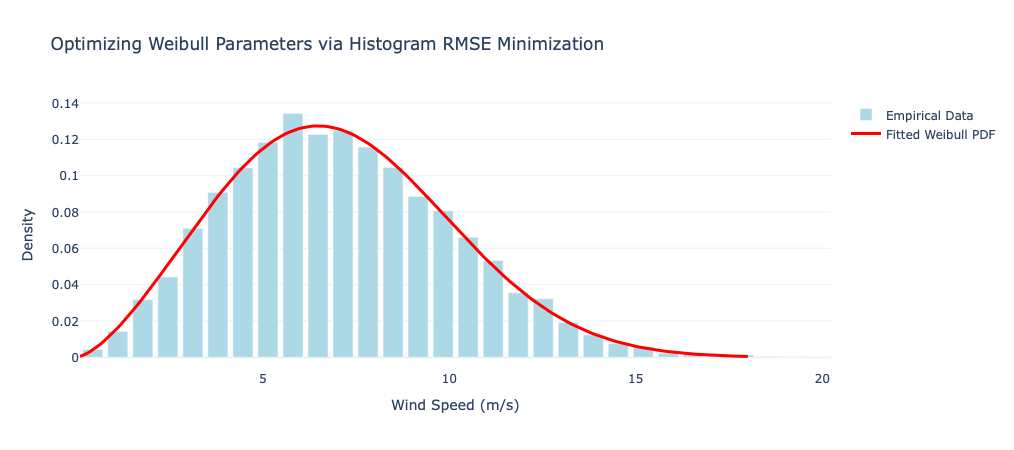

In [22]:
import numpy as np
import plotly.graph_objects as go
import scipy.optimize as optimize
import scipy.stats as stats

# Generate mock wind speed data (Weibull distributed)
np.random.seed(12)
true_beta = 2.5  # Shape parameter
true_eta = 8.0  # Scale parameter (m/s)
wind_data = stats.weibull_min.rvs(c=true_beta, scale=true_eta, size=10000)

# Construct a density-normalized histogram
num_bins = 30
counts, bin_edges = np.histogram(wind_data, bins=num_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


# Objective Function to minimize (RMSE)
def rmse_objective(params):
    beta, eta = params
    if beta <= 0 or eta <= 0:
        return 1e6  # Penalty for invalid boundaries

    # Evaluate theoretical Weibull PDF at bin centers
    theoretical_pdf = stats.weibull_min.pdf(bin_centers, c=beta, scale=eta)

    # Return RMSE
    return np.sqrt(np.mean((counts - theoretical_pdf) ** 2))


# Perform Gradient Descent numerical minimization
initial_guess = [1.0, 5.0]
optimization_result = optimize.minimize(rmse_objective, initial_guess)
est_beta, est_eta = optimization_result.x

print("--- Task 2 Optimization Solution ---")
print(f"True Parameters:      beta = {true_beta:.2f}, eta = {true_eta:.2f}")
print(f"Estimated Parameters: beta = {est_beta:.2f}, eta = {est_eta:.2f}")

# Plotting the optimized fit
x_plot = np.linspace(0.1, 18, 200)
fitted_pdf = stats.weibull_min.pdf(x_plot, c=est_beta, scale=est_eta)

fig = go.Figure()
fig.add_trace(
    go.Bar(x=bin_centers, y=counts, name="Empirical Data", marker_color="lightblue")
)
fig.add_trace(
    go.Scatter(
        x=x_plot,
        y=fitted_pdf,
        mode="lines",
        name="Fitted Weibull PDF",
        line=dict(color="red", width=3),
    )
)
fig.update_layout(
    title="Optimizing Weibull Parameters via Histogram RMSE Minimization",
    xaxis_title="Wind Speed (m/s)",
    yaxis_title="Density",
    template="plotly_white",
    height=450,
)
fig.show()

---
## 💡 Optional Visual Aid: Exploring Bimodal Profiles

*Note: This interactive visualization is designed to help you build conceptual intuition. It is not tested on the final exam.*

Slide `20260630b.png` notes that distributions are not always single-humped; they can be **bimodal**, meaning they exhibit two distinct local modes (peaks). 

Run the cell below to load an interactive dashboard of a two-component **Gaussian Mixture Model (GMM)**. Move the sliders to shift the means ($\mu_1, \mu_2$), standard deviations ($\sigma_1, \sigma_2$), and the blending weight ($w$). Watch how the peaks split and merge, and see how the total mean and variance react!

In [23]:
import ipywidgets as widgets
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats
from IPython.display import display

fig = go.FigureWidget()
x_vals = np.linspace(-10, 20, 400)

fig.add_trace(
    go.Scatter(
        x=x_vals,
        y=np.zeros_like(x_vals),
        mode="lines",
        line=dict(color="purple", width=3),
        name="Mixture PDF",
    )
)
fig.add_vline(
    x=0.0, line_dash="dash", line_color="orange", annotation_text="Total Mean"
)

fig.update_layout(
    title="Bimodal Mixture PDF and Global Properties",
    xaxis_title="Value (x)",
    yaxis_title="Probability Density",
    template="plotly_white",
    height=450,
    yaxis=dict(range=[0, 0.4]),
)

mu1_slider = widgets.FloatSlider(
    value=0.0, min=-5.0, max=5.0, step=0.1, description="μ1:", continuous_update=False
)
sigma1_slider = widgets.FloatSlider(
    value=1.5, min=0.5, max=3.0, step=0.1, description="σ1:", continuous_update=False
)
mu2_slider = widgets.FloatSlider(
    value=8.0, min=4.0, max=15.0, step=0.1, description="μ2:", continuous_update=False
)
sigma2_slider = widgets.FloatSlider(
    value=2.0, min=0.5, max=3.0, step=0.1, description="σ2:", continuous_update=False
)
weight_slider = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=0.9,
    step=0.05,
    description="Weight (w):",
    continuous_update=False,
)


def update_mixture(change):
    mu1, sig1 = mu1_slider.value, sigma1_slider.value
    mu2, sig2 = mu2_slider.value, sigma2_slider.value
    w = weight_slider.value

    mixture_pdf = w * stats.norm.pdf(x_vals, loc=mu1, scale=sig1) + (
        1 - w
    ) * stats.norm.pdf(x_vals, loc=mu2, scale=sig2)
    global_mean = w * mu1 + (1 - w) * mu2
    ex2 = w * (sig1**2 + mu1**2) + (1 - w) * (sig2**2 + mu2**2)
    global_variance = ex2 - (global_mean**2)

    with fig.batch_update():
        fig.data[0].y = mixture_pdf
        fig.layout.annotations[0].x = global_mean
        fig.layout.title.text = f"Bimodal PDF (Global Mean = {global_mean:.2f}, Global Variance = {global_variance:.2f})"


for slider in [mu1_slider, sigma1_slider, mu2_slider, sigma2_slider, weight_slider]:
    slider.observe(update_mixture, names="value")

update_mixture(None)
display(
    widgets.HBox(
        [
            widgets.VBox([mu1_slider, sigma1_slider]),
            widgets.VBox([mu2_slider, sigma2_slider]),
            weight_slider,
        ]
    ),
    fig,
)

FigureWidget({
    'data': [{'line': {'color': 'purple', 'width': 3},
              'mode': 'lines',
              'name': 'Mixture PDF',
              'type': 'scatter',
              'uid': 'fc1e59c9-0f28-44ad-8732-611d150b155e',
              'x': {'bdata': ('AAAAAAAAJMCYPWD2gNkjwDB7wOwBsy' ... 'D2gNkzQMweMHvA7DNAAAAAAAAANEA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('o7m9Y1NUwD3U41jmqMfGPb5mWczlss' ... 'yFqm0kPpEXTO55ViA+/YfQ+4AYGj4='),
                    'dtype': 'f8'}}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'Total Mean',
                                'x': 4.0,
                                'xanchor': 'left',
                                'xref': 'x',
                                'y': 1,
                                'yanchor': 'top',
                                'yref': 'y domain'}],
               'height': 450,
               'shapes': [{'line': {'color': 'orange', 'dash': 'dash'},
